# Overview
This notebooks is intended to estimate net worth change for two housing strategies over different time horizons and under different assumptions.

# Notation
## Big Idea
We are tracking net worth over time:

$$
\text{NW}_s(t) = \text{Assets}_s(t) - \text{Liabilities}_s(t)
$$

for $s\in\{ \text{Rent}, \text{Buy}  \}$ with special interest in the quantity:

$$
\Delta(t) = \text{NW}_{buy}(t) - \text{NW}_{rent}(t)
$$

for $t \in \{ 1, 2, 3, 5, 7 \}$ years.

For a subset of the parameter space, we will run Monte Carlo simulations to estimate the distribution of $\Delta(t)$.

# Imports

In [17]:
import numpy as np
import pandas as pd

from housing.params import (
    MarginalDist, StochasticParams, DeterministicParams, DEFAULT_CORRELATION,
)
from housing.simulation import run_monte_carlo
from housing.plotting import (
    delta_summary, plot_delta_violin, plot_prob_buy_wins,
    plot_delta_fan, plot_net_worth_comparison,
)

# Setup

In [18]:
stochastic_params = StochasticParams(
    appreciation=MarginalDist(mean=0.06, std=0.06),
    investment_return=MarginalDist(mean=0.07, std=0.15),
    rent_growth=MarginalDist(mean=0.03, std=0.02),
    correlation=DEFAULT_CORRELATION
)

deterministic_params = DeterministicParams(
    home_price=500_000,
    down_payment=100_000,
    interest_rate=0.065,
    loan_term_years=30,
    property_tax_rate=0.012,
    hoa_monthly=350,
    insurance_monthly=150,
    maintenance_rate=0.01,
    buy_closing_cost_rate=0.03,
    sell_transaction_cost_rate=0.06,
    rent_monthly_initial=2_500,
    initial_savings=150_000,
    monthly_income=8_000,
    ltcg_rate=0.15,
    stcg_rate=0.24,
    home_sale_exclusion=250_000,
    marginal_tax_rate=0.24,
    standard_deduction=14_600,
    salt_deduction=10_000,
)

horizons = list(range(1, 11))

rng = np.random.default_rng(42)

# Simulation

In [19]:
results = run_monte_carlo(deterministic_params, stochastic_params, n_trials=1_000, rng=rng, horizons=horizons)

## Summary Statistics

In [20]:
delta_summary(results)

,mean,median,std,p10,p25,p75,p90,prob_buy_wins
horizon_years,,,,,,,,
1,"$-36,793","$-36,166","$22,388","$-65,398","$-50,485","$-22,275","$-9,964",5.0%
2,"$-14,286","$-14,386","$42,126","$-67,160","$-42,642","$13,225","$39,032",36.1%
3,"$1,044",$549,"$55,208","$-68,763","$-31,207","$37,955","$68,472",50.4%
4,"$17,668","$17,105","$66,850","$-65,602","$-28,834","$64,556","$100,837",58.0%
5,"$34,056","$34,801","$77,231","$-66,354","$-18,791","$84,729","$131,388",68.3%
6,"$51,777","$50,282","$88,688","$-58,907","$-10,183","$111,674","$164,003",71.3%
7,"$67,752","$68,420","$106,051","$-66,491","$-6,860","$137,466","$198,796",73.3%
8,"$83,267","$85,023","$122,145","$-71,067","$7,470","$163,400","$240,129",76.9%
9,"$96,565","$94,187","$136,948","$-70,137","$17,276","$183,039","$269,018",79.0%


## Distribution by Horizon

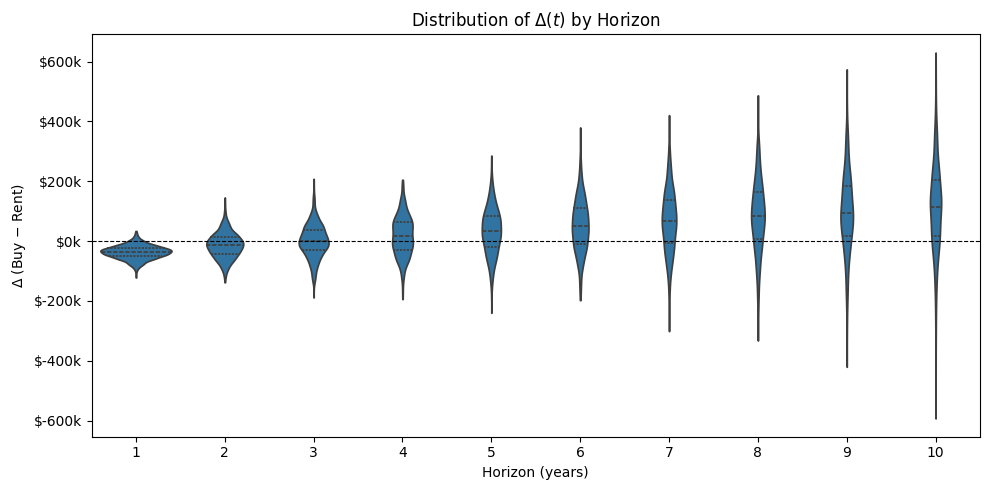

In [21]:
plot_delta_violin(results);

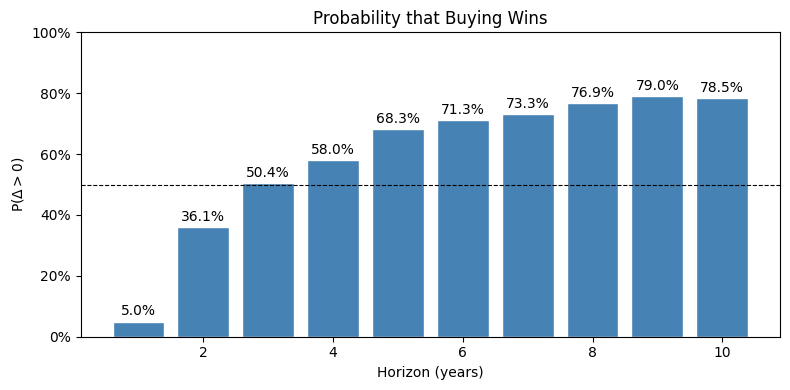

In [22]:
plot_prob_buy_wins(results);

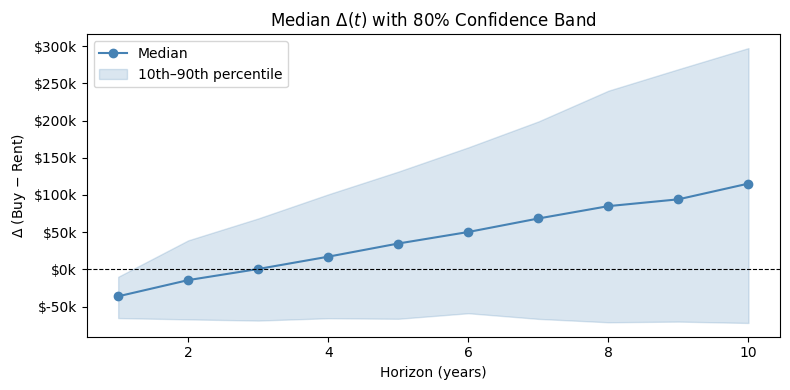

In [23]:
plot_delta_fan(results);

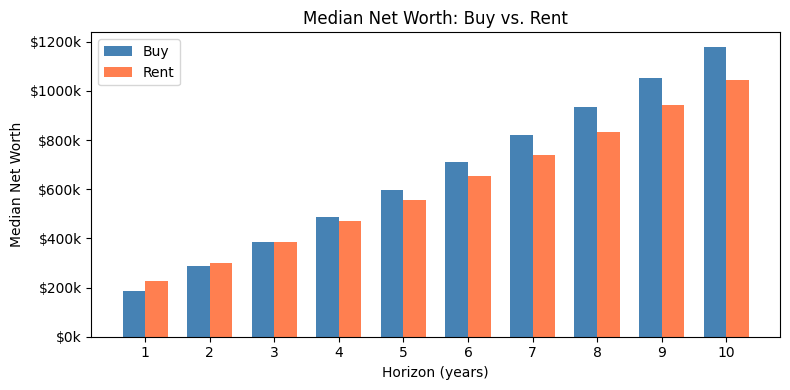

In [24]:
plot_net_worth_comparison(results);